In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
from scipy.special import inv_boxcox
from scipy.stats import yeojohnson
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima.arima import auto_arima
from scipy.signal import periodogram
import pmdarima as pm
from pmdarima.arima import nsdiffs, ndiffs
import matplotlib.dates as mdates


In [19]:
def run_sarima_pipeline(series,
                        order=(1,0,1),
                        seasonal_order=(0,0,0,0),
                        trend='c',
                        test_size=12,
                        title='SARIMA Model'):

    import numpy as np
    import matplotlib.pyplot as plt
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    # --- Split ---
    train = series[:-test_size]
    test  = series[-test_size:]

    # --- Fit ---
    model = SARIMAX(train,
                    order=order,
                    seasonal_order=seasonal_order,
                    trend=trend)

    result = model.fit(disp=False)

    # --- In-sample ---
    fitted_train = result.fittedvalues

    # --- Forecast ---
    forecast_obj  = result.get_forecast(steps=test_size)
    forecast_mean = forecast_obj.predicted_mean
    conf_int      = forecast_obj.conf_int(alpha=0.05)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train.index, train,         label='Train Actual',  alpha=0.6)
    ax.plot(train.index, fitted_train,  label='Train Fitted',  linewidth=1.5)
    ax.plot(test.index,  test,          label='Test Actual',   linewidth=2)
    ax.plot(test.index,  forecast_mean, label='Forecast',      linestyle='--')

    ax.fill_between(test.index,
                    conf_int.iloc[:, 0],
                    conf_int.iloc[:, 1],
                    alpha=0.2,
                    label='95% CI')

    ax.axvline(x=train.index[-1], linestyle=':', linewidth=1.5)
    ax.set_title(title)
    ax.legend()

    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # --- Metrics ---
    mae  = mean_absolute_error(test, forecast_mean)
    rmse = np.sqrt(mean_squared_error(test, forecast_mean))

    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")

    return {
        "model": result,
        "forecast": forecast_mean,
        "conf_int": conf_int,
        "mae": mae,
        "rmse": rmse
    }

# **UK Credit**

In [ ]:
df_UK = pd.read_csv("Data/MacroVariables_UK_Q.csv", index_col=0)
Credit = df_UK[["uk_credit_yoy_growth"]].copy().dropna()
series = Credit['uk_credit_yoy_growth'].dropna()  # Ensure no NaN values for transformations
Credit.index = pd.to_datetime(Credit.index)


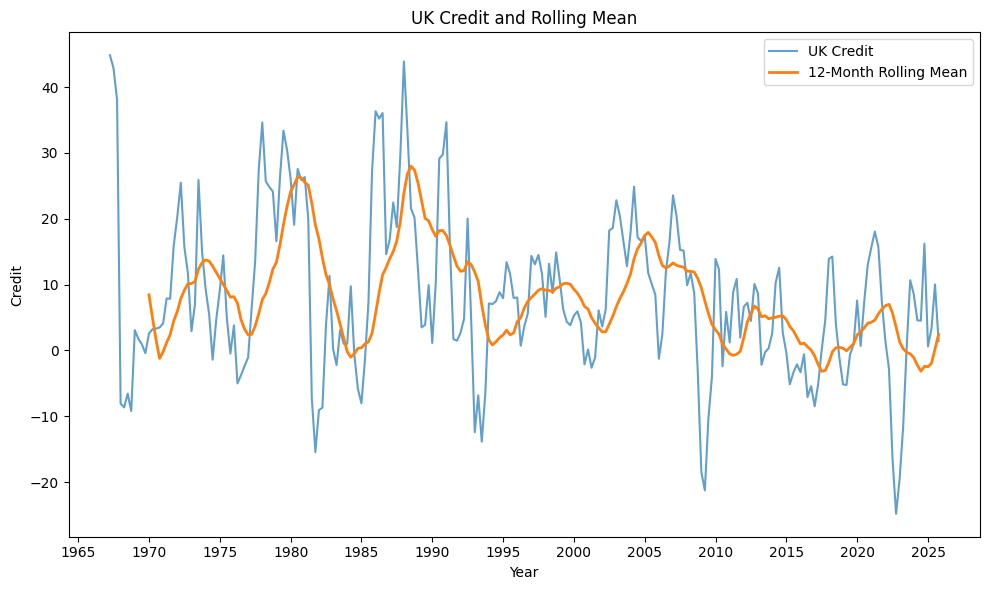

In [ ]:

rolling_mean = Credit.rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(Credit.index, Credit, label='UK Credit', alpha=0.7)
ax.plot(Credit.index, rolling_mean, label='12-Month Rolling Mean', linewidth=2)

ax.set_title('UK Credit and Rolling Mean')

# Major ticks: once per year
ax.xaxis.set_major_locator(mdates.YearLocator())

ax.xaxis.set_major_locator(mdates.YearLocator(5))   # every 5 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_xlabel('Year')
ax.set_ylabel('Credit')
ax.legend()

plt.tight_layout()
plt.show()

In [71]:
result = adfuller(series, autolag='AIC')
p_value = result[1]
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {p_value}')

ADF Statistic: -4.491750899317175
p-value: 0.00020350003875270698


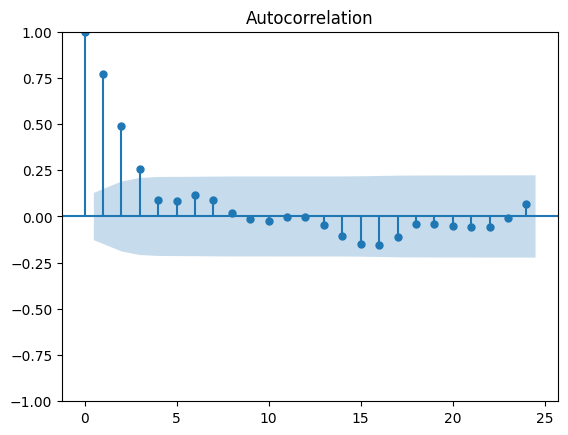

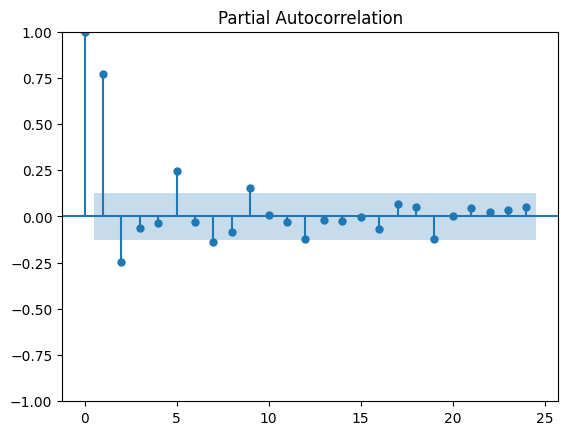

In [72]:
plot_acf(series)
plot_pacf(series)
plt.show()

In [ ]:
# ── d: Non-seasonal differencing ─────────────────────────────────────────────
adf_p = adfuller(series, autolag='AIC')[1]
kpss_p = kpss(series, regression='c', nlags='auto')[1]
pp_p = ndiffs(series, test='pp')

print("── d (Non-seasonal differencing) ──")
print(f"ADF p-value:         {adf_p:.4f}  → {'Stationary' if adf_p < 0.05 else 'Non-stationary'}")
print(f"KPSS p-value:        {kpss_p:.4f}  → {'Non-stationary' if kpss_p < 0.05 else 'Stationary'}")
print(f"PP suggested d:      {pp_p}")
print(f"Suggested d:         {ndiffs(series, test='adf')}\n")

# ── s: Seasonal period ───────────────────────────────────────────────────────
freqs, power = periodogram(series.dropna())
dominant_freq = freqs[np.argmax(power[1:]) + 1]  # skip DC component
s_periodogram = round(1 / dominant_freq)

acf_values = acf(series.dropna(), nlags=50)
seasonal_lags = [i for i in range(2, 50) if acf_values[i] > 0.2]  # spikes above threshold

print("── s (Seasonal period) ──")
print(f"Periodogram suggested s: {s_periodogram}")
print(f"ACF spikes at lags:      {seasonal_lags[:5]}")
print(f"(Confirm with domain knowledge — monthly=12, quarterly=4)\n")

# ── D: Seasonal differencing ─────────────────────────────────────────────────
m = 4  # set your seasonal period here

D_ch  = nsdiffs(series, m=m, test='ch')   # Canova-Hansen
D_ocsb = nsdiffs(series, m=m, test='ocsb') # OCSB

print("── D (Seasonal differencing) ──")
print(f"Canova-Hansen suggested D: {D_ch}")
print(f"OCSB suggested D:          {D_ocsb}\n")

# ── p, q, P, Q: Orders via AIC/BIC ───────────────────────────────────────────
print("── p, q, P, Q (via auto_arima AIC search) ──")
model = pm.auto_arima(series,
                      seasonal=True, m=m,
                      d=ndiffs(series, test='adf'),   # feed in test result
                      D=D_ocsb,
                      information_criterion='aic',
                      stepwise=True,
                      trace=True)

print(f"\nBest model: SARIMA{model.order}x{model.seasonal_order}")
print(model.summary())

── d (Non-seasonal differencing) ──
ADF p-value:         0.0002  → Stationary
KPSS p-value:        0.0388  → Non-stationary
PP suggested d:      0
Suggested d:         0

── s (Seasonal period) ──
Periodogram suggested s: 34
ACF spikes at lags:      [2, 3, 30, 31, 32]
(Confirm with domain knowledge — monthly=12, quarterly=4)

── D (Seasonal differencing) ──
Canova-Hansen suggested D: 0
OCSB suggested D:          0

── p, q, P, Q (via auto_arima AIC search) ──
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[4] intercept   : AIC=1542.866, Time=0.58 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=1844.628, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=1586.315, Time=0.33 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=1657.967, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=1930.022, Time=0.02 sec
 ARIMA(2,0,2)(0,0,1)[4] intercept   : AIC=1542.024, Time=0.21 sec
 ARIMA(2,0,2)(0,0,0)[4] intercept   : AIC=1594.670, Time=0.13 sec
 ARIMA(2,0,2)(0,0,2)[4] interce

/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


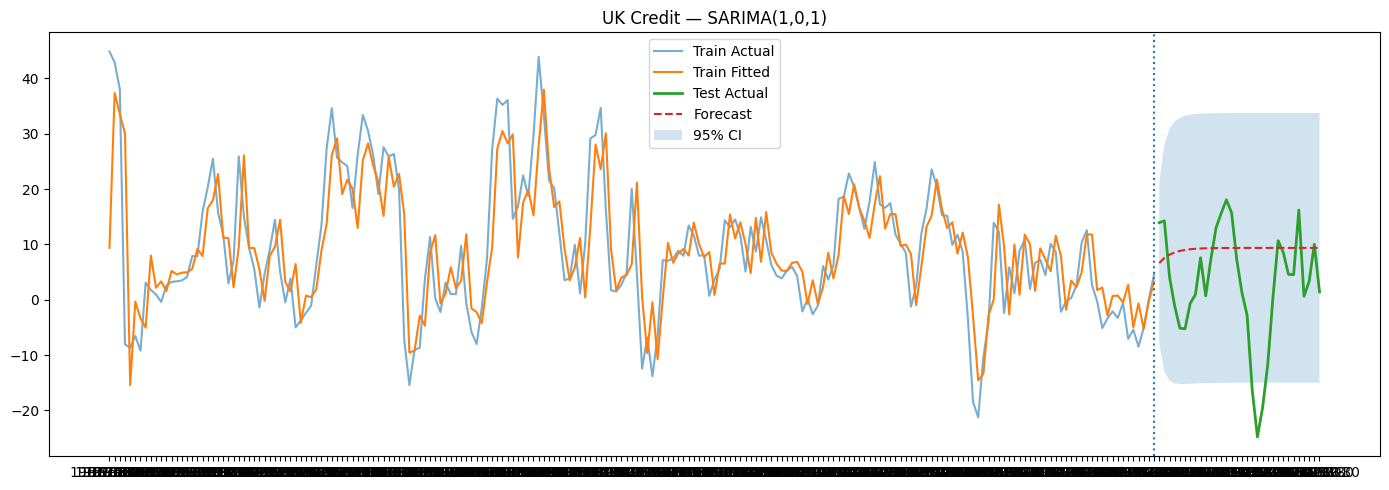

MAE:  9.204
RMSE: 12.117


/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


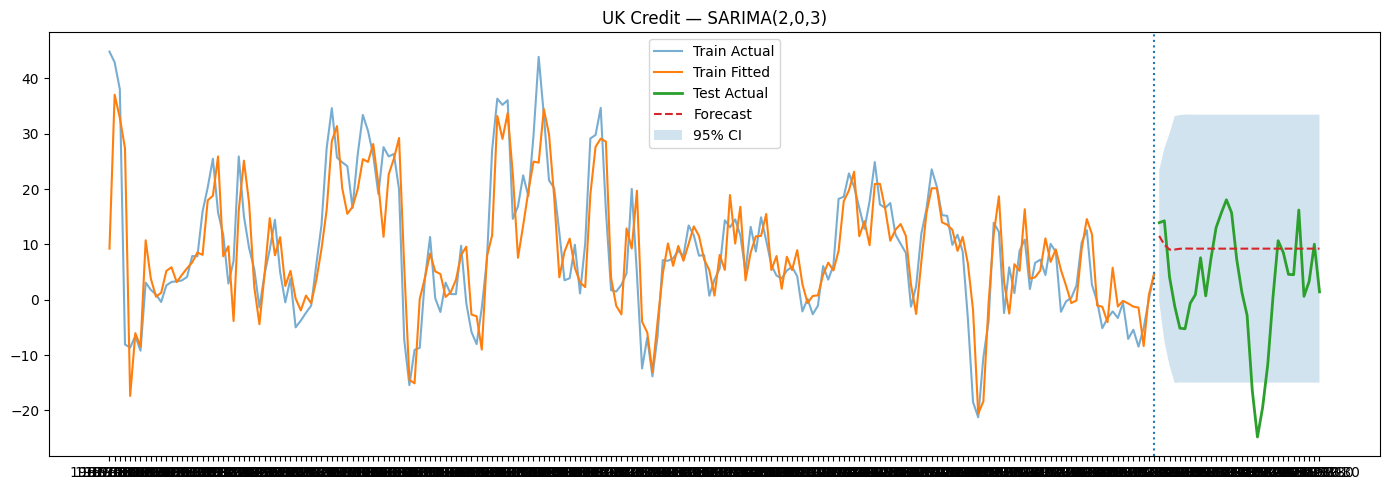

MAE:  9.008
RMSE: 12.021


In [74]:
baseline = run_sarima_pipeline(series, (1,0,1), (0,0,0,4), test_size=32, title='UK Credit — SARIMA(1,0,1)')
AIC_Fit = run_sarima_pipeline(series, (2,0,3), (0,0,0,4), test_size=32, title='UK Credit — SARIMA(2,0,3)')

In [76]:
resid = baseline['model'].resid.dropna()

stat, p, _, _ = het_arch(resid)
print(f"ARCH p-value: {p:.4f}")


ARCH p-value: 0.3604


# **US Credit**

In [4]:
import os

In [5]:
os.chdir('/Users/dannyhogan/Desktop/ST-498')


In [21]:
df_US = pd.read_csv("Data/MacroVariables_US_Q.csv", index_col=0)
Credit = df_US[["us_credit_yoy_growth"]].copy().dropna()
series = Credit['us_credit_yoy_growth'].dropna()  # Ensure no NaN values for transformations
Credit.index = pd.to_datetime(Credit.index)


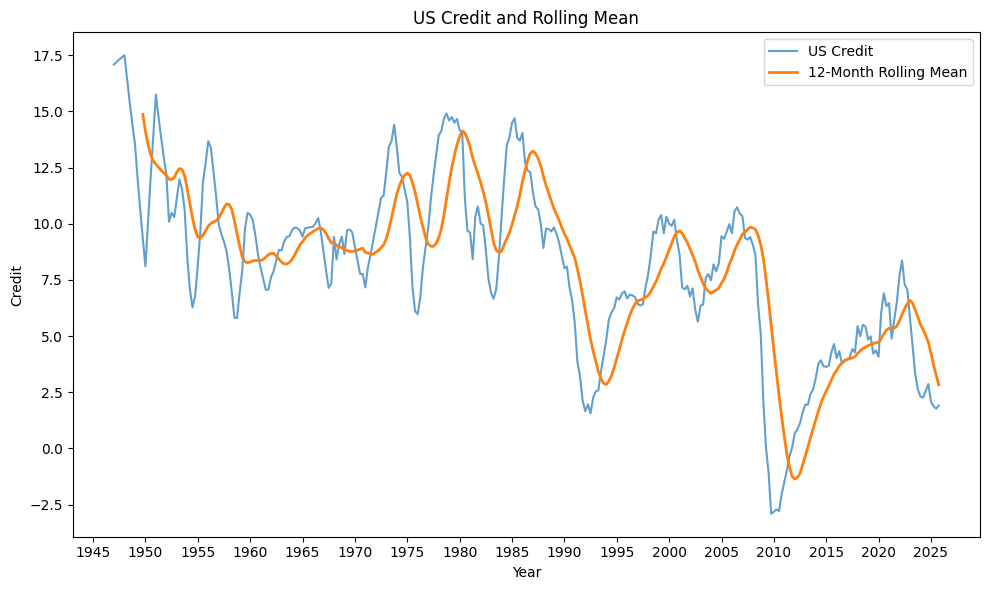

In [13]:
rolling_mean = Credit.rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(Credit.index, Credit, label='US Credit', alpha=0.7)
ax.plot(Credit.index, rolling_mean, label='12-Month Rolling Mean', linewidth=2)

ax.set_title('US Credit and Rolling Mean')

# Major ticks: once per year
ax.xaxis.set_major_locator(mdates.YearLocator())

ax.xaxis.set_major_locator(mdates.YearLocator(5))   # every 5 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_xlabel('Year')
ax.set_ylabel('Credit')
ax.legend()

plt.tight_layout()
plt.show()

In [10]:
result = adfuller(series, autolag='AIC')
p_value = result[1]
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {p_value}')

ADF Statistic: -1.8134900917009418
p-value: 0.37378510335716086


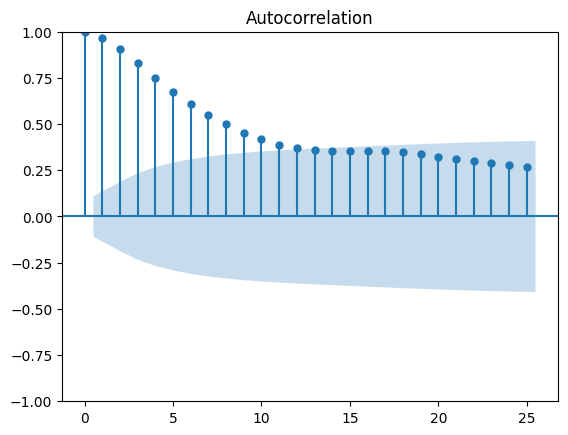

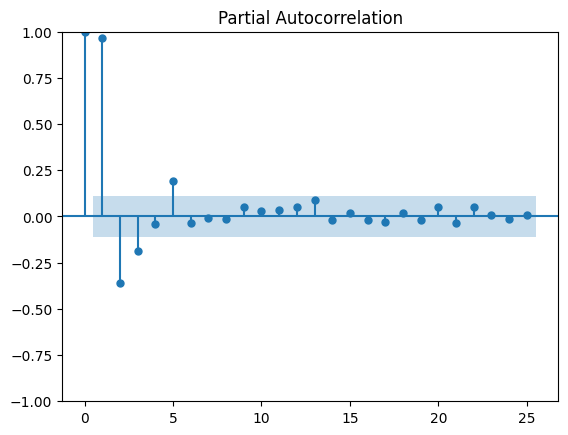

In [22]:
plot_acf(series)
plot_pacf(series)
plt.show()

In [17]:
# ── d: Non-seasonal differencing ─────────────────────────────────────────────
adf_p = adfuller(series, autolag='AIC')[1]
kpss_p = kpss(series, regression='c', nlags='auto')[1]
pp_p = ndiffs(series, test='pp')

print("── d (Non-seasonal differencing) ──")
print(f"ADF p-value:         {adf_p:.4f}  → {'Stationary' if adf_p < 0.05 else 'Non-stationary'}")
print(f"KPSS p-value:        {kpss_p:.4f}  → {'Non-stationary' if kpss_p < 0.05 else 'Stationary'}")
print(f"PP suggested d:      {pp_p}")
print(f"Suggested d:         {ndiffs(series, test='adf')}\n")


# ── s: Seasonal period ───────────────────────────────────────────────────────
freqs, power = periodogram(series.dropna())
dominant_freq = freqs[np.argmax(power[1:]) + 1]  # skip DC component
s_periodogram = round(1 / dominant_freq)

acf_values = acf(series.dropna(), nlags=50)
seasonal_lags = [i for i in range(2, 50) if acf_values[i] > 0.2]  # spikes above threshold

print("── s (Seasonal period) ──")
print(f"Periodogram suggested s: {s_periodogram}")
print(f"ACF spikes at lags:      {seasonal_lags[:5]}")
print(f"(Confirm with domain knowledge — monthly=12, quarterly=4)\n")

# ── D: Seasonal differencing ─────────────────────────────────────────────────
m = 4  # set your seasonal period here

D_ch  = nsdiffs(series, m=m, test='ch')   # Canova-Hansen
D_ocsb = nsdiffs(series, m=m, test='ocsb') # OCSB

print("── D (Seasonal differencing) ──")
print(f"Canova-Hansen suggested D: {D_ch}")
print(f"OCSB suggested D:          {D_ocsb}\n")

# ── p, q, P, Q: Orders via AIC/BIC ───────────────────────────────────────────
print("── p, q, P, Q (via auto_arima AIC search) ──")
# 1. Fix the d selection logic — PP should NOT override ADF+KPSS consensus
if adf_p > 0.05 and kpss_p < 0.05:
    suggested_d = 1          # both agree → difference
elif adf_p > 0.05:
    suggested_d = 1          # ADF alone says unit root
elif kpss_p < 0.05:
    suggested_d = 1          # KPSS alone says non-stationary  
else:
    suggested_d = 0          # both say stationary

# 2. Let auto_arima SEARCH over d rather than fixing it
model = auto_arima(
    series,
    d=None,          # ← was d=suggested_d, which locked it to 0
    max_d=2,
    start_p=1, max_p=4,
    start_q=0, max_q=4,
    seasonal=True, m=4,
    D=0,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True
)

print(f"\nBest model: SARIMA{model.order}x{model.seasonal_order}")
print(model.summary())

/var/folders/ts/x847bxb170n3msnnpmdpjll00000gn/T/ipykernel_2521/1375416200.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series, regression='c', nlags='auto')[1]


── d (Non-seasonal differencing) ──
ADF p-value:         0.3738  → Non-stationary
KPSS p-value:        0.0100  → Non-stationary
PP suggested d:      0
Suggested d:         0

── s (Seasonal period) ──
Periodogram suggested s: 316
ACF spikes at lags:      [2, 3, 4, 5, 6]
(Confirm with domain knowledge — monthly=12, quarterly=4)

── D (Seasonal differencing) ──
Canova-Hansen suggested D: 0
OCSB suggested D:          0

── p, q, P, Q (via auto_arima AIC search) ──

Best model: SARIMA(3, 1, 1)x(0, 0, 1, 4)
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  316
Model:             SARIMAX(3, 1, 1)x(0, 0, 1, 4)   Log Likelihood                -276.487
Date:                           Mon, 13 Apr 2026   AIC                            566.974
Time:                                   16:01:39   BIC                            593.242
Sample:                               12-3

/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


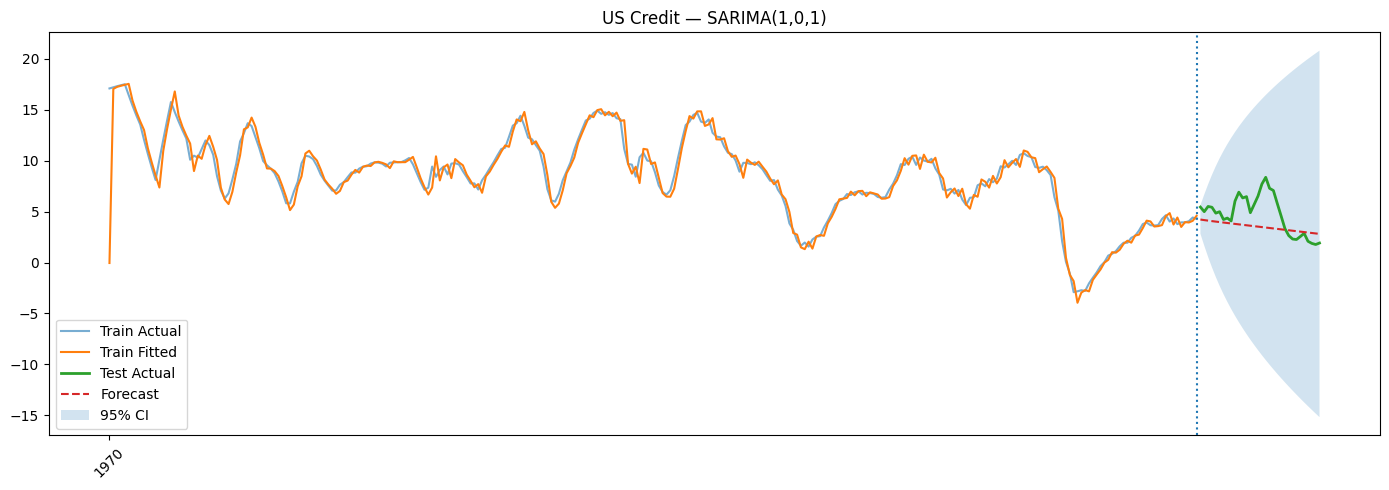

MAE:  1.634
RMSE: 2.076


/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
/Users/dannyhogan/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


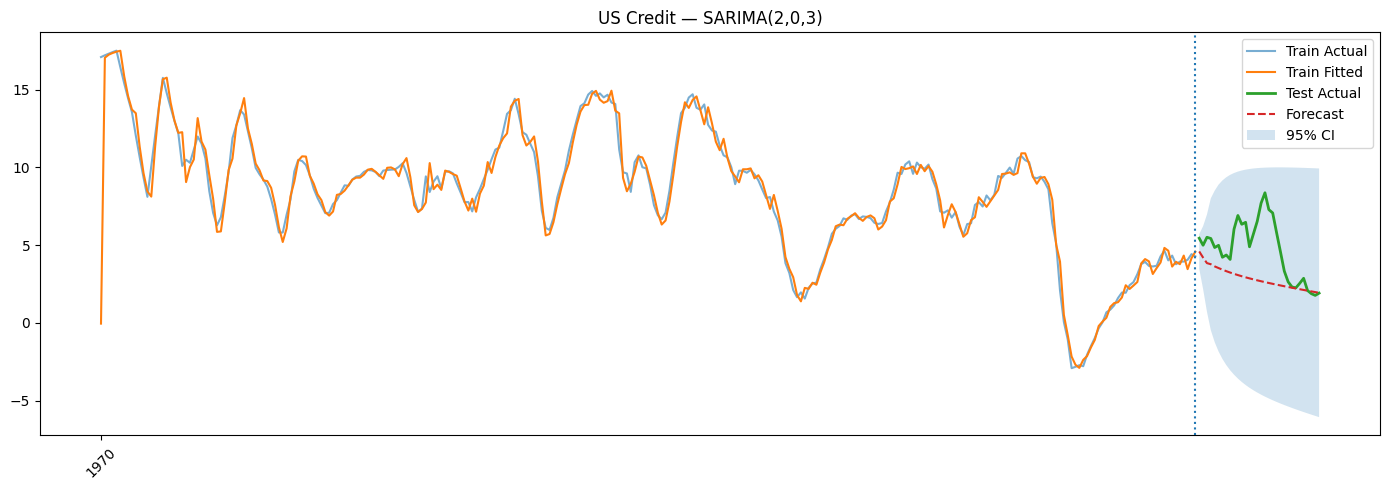

MAE:  1.910
RMSE: 2.534


In [20]:
baseline = run_sarima_pipeline(series, (1,1,1), (0,0,0,4), test_size=32, title='US Credit — SARIMA(1,0,1)')
AIC_Fit = run_sarima_pipeline(series, (3,1,1), (0,0,1,4), test_size=32, title='US Credit — SARIMA(2,0,3)')